# setting libraries up and functions

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
## i want to import function from preprocessing.py file to use it in this notebook
'''with open('D:/Courses/رواد مصر الرقمية/Techanical/python/CA-R5-S2S2-AI/src/DA_workshop/session-1/assignment/project/preprocessing.py') as f:
    check_data = f.read()
    
from preprocessing.py import Check_data_type'''

"with open('D:/Courses/رواد مصر الرقمية/Techanical/python/CA-R5-S2S2-AI/src/DA_workshop/session-1/assignment/project/preprocessing.py') as f:\n    check_data = f.read()\n\nfrom preprocessing.py import Check_data_type"

In [32]:
df = pd.read_csv('insurance.csv')


# understand business

# understand data

In [33]:


df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Drop Non interest features 

In [35]:
## Drop the columns that are not needed for analysis. In this case, we will drop the 'region' column.
df = df.drop('region', axis=1)

In [36]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


# check data types

In [37]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,age,sex,bmi,children,smoker,charges
Dtype,int64,str,float64,int64,str,float64
Num_Uniqe,47,2,548,6,2,1337


# handle dtypes

# check nulls 

In [19]:
null = df.isnull().sum()

In [30]:
print(f"Number of null values in the dataset:\n{null}")

Number of null values in the dataset:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# check outliers

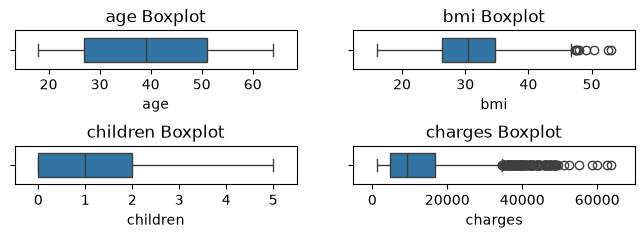

In [54]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,2))
for i , col in enumerate(num_cols ):
    plt.subplot(2,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.margins(x=0.1, y=.3)
    plt.subplots_adjust(hspace=2)
    plt.title(f"{col} Boxplot")

# handle outliers

In [57]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence)
    df[col].replace(Upper_Outliers, Upper_Fence)

# check duplicated

In [58]:
df.duplicated().sum()

np.int64(1)

# handle duplicated

In [59]:
df.drop_duplicates(inplace= True)

In [60]:
df.duplicated().sum()

np.int64(0)

# data visualization

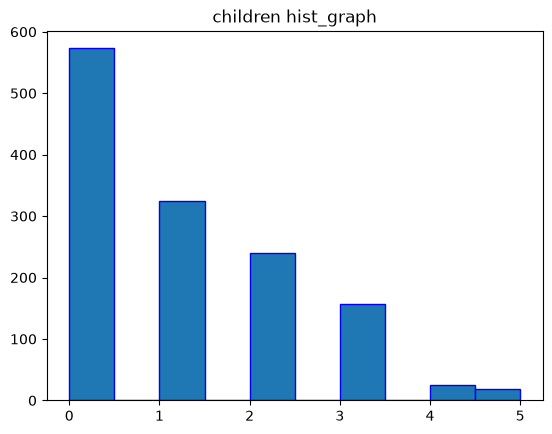

In [69]:
plt.hist(df['children'], edgecolor = "blue")
plt.title(f"children hist_graph")
plt.show()

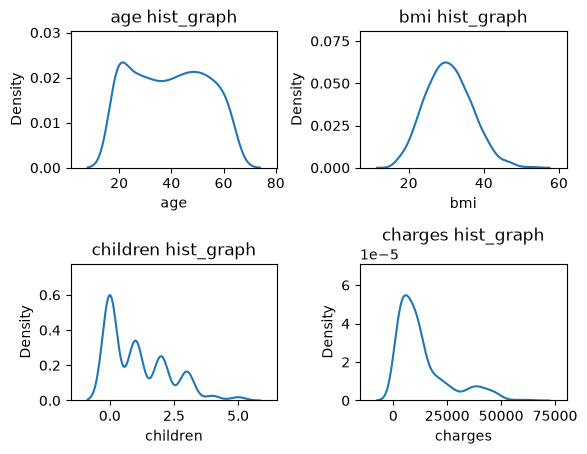

In [67]:
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
    plt.margins(x=0.1, y=.3)
    plt.subplots_adjust(hspace=0.7,wspace=0.4)
plt.show()

C:\Users\COMPUMARTS\AppData\Local\Temp\ipykernel_21604\3199538909.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes("object").columns


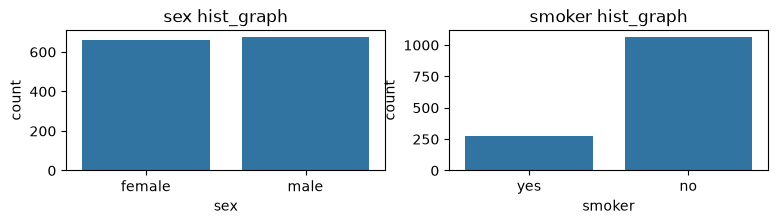

In [74]:
cat_cols = df.select_dtypes("object").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.show()

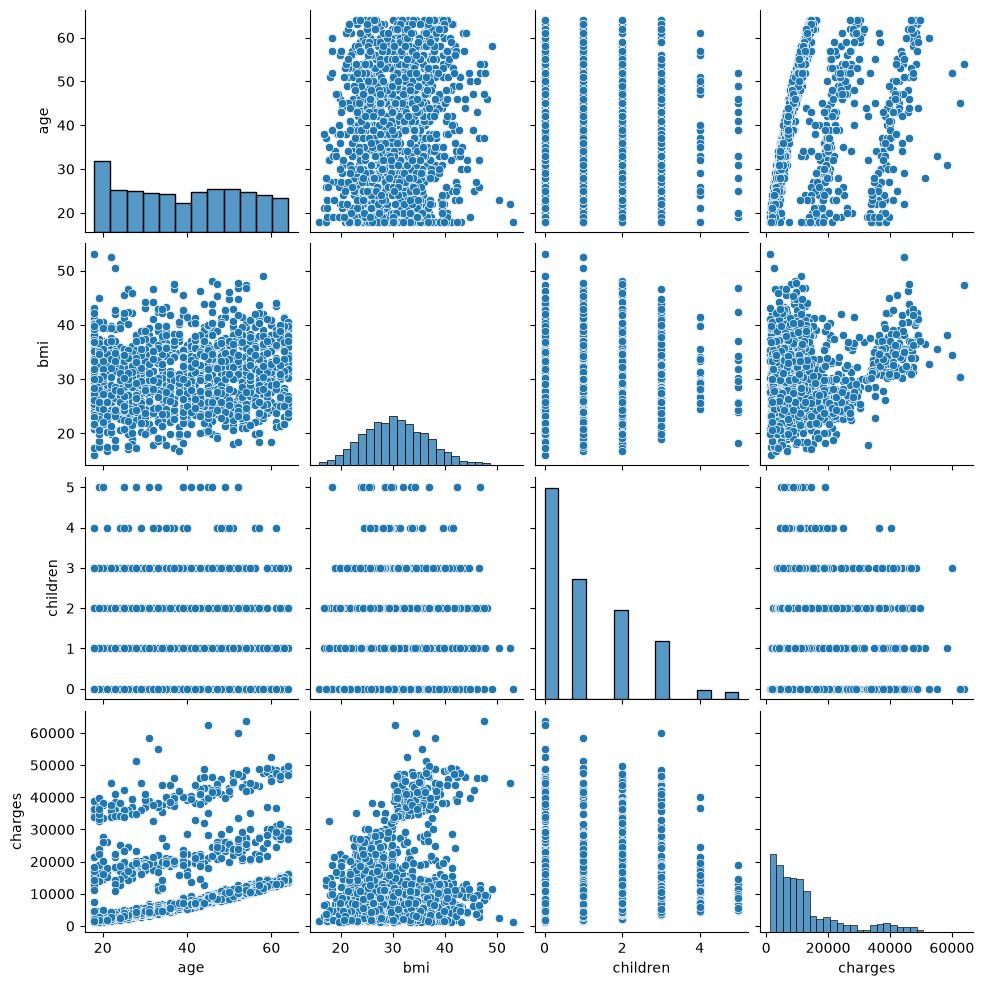

In [75]:
sns.pairplot(df)

# Data spliting

# normalization

# encoding

In [77]:
# male -> 0, female -> 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [80]:
# non-smoker -> 0, smoker -> 1
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [81]:
print(df.head())

   age  sex     bmi  children  smoker      charges
0   19    1  27.900         0       1  16884.92400
1   18    0  33.770         1       0   1725.55230
2   28    0  33.000         3       0   4449.46200
3   33    0  22.705         0       0  21984.47061
4   32    0  28.880         0       0   3866.85520
